<a href="https://colab.research.google.com/github/ikabrain/UCS761-Deep-Learning-Lab/blob/main/DL_assign6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6 - Implementation of different optimizations
---

## Initialising
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Base Classes
---

In [2]:
class Layer:
    """
    Base class for all layers of the neural network (including activation).
    """
    def forward(self, X):
        raise NotImplementedError

    def __call__(self, X):
        return self.forward(X)

    def backward(self, dA):
        # Here, dA is the activated gradient from the NEXT layer that has propagated to here for current output!
        raise NotImplementedError

    def _update(self, lr):
        # We update all the layers AFTER all the gradients have propagated through the network!
        pass # Can be left blank for activation layers which have no parameters

In [3]:
class Optimizer:
    """
    Base optimizer class.
    """
    def __init__(self, lr=0.001):
        self.lr = lr

    def update(self, layer):
        """
        Updates parameters of a given layer.
        """
        raise NotImplementedError

    def __call__(self, layer):
        self.update(layer)

    def plot(self,
             loss_fn=lambda w1, w2: w1**2 + 5*w2**2,
             start=(-4, 3),
             max_iter=100,
             w1_min=-5,
             w1_max=5,
             w2_min=-5,
             w2_max=5,
             n_contours=35,
             title="Optimization Algo on Loss Contour"
    ):
        """
        Visualises the optimiser's trajectory on a 2D loss surface.

        Parameters
        ----------
        loss_fn         : function(w1, w2) -> Returns scalar
                          Default: elongated bowl w1^2 + 5*w2^2.
        start           : (w1, w2) starting point for the trajectory.
        max_iter        : number of update steps to run.
        w1_min, w1_max  : Range for the w1 weight.
        w2_min, w2_max  : Range for the w2 weight.
        n_contours      : number of contour levels drawn.
        title           : plot title. Defaults to class name + hyperparams.
        """
        # Initialising a MockLayer
        class _MockLayer:
            pass
        layer = _MockLayer()
        layer.W = np.array([[start[0], start[1]]], dtype=float)
        layer.b = np.zeros((1, 1))
        layer.dW = np.zeros((1, 2))
        layer.db = np.zeros((1, 1))

        path = [layer.W.flatten().copy()]
        h = 1e-5 # Difference step to approximate CURRENT gradient
        for _ in range(max_iter):
            w1, w2 = layer.W[0, 0], layer.W[0, 1]
            layer.dW[0, 0] = (loss_fn(w1+h, w2) - loss_fn(w1-h, w2)) / (2 * h)
            layer.dW[0, 1] = (loss_fn(w1, w2+h) - loss_fn(w1, w2-h)) / (2 * h)
            self.update(layer)
            path.append(layer.W.flatten().copy())
        path = np.array(path)

        # Draw contour + trajectory
        w1 = np.linspace(w1_min, w1_max, 400)
        w2 = np.linspace(w2_min, w2_max, 400)
        W1, W2 = np.meshgrid(w1, w2)
        Z = loss_fn(W1, W2)

        plt.contourf(W1, W2, Z, levels=n_contours, cmap="Reds")
        plt.colorbar(label="Loss")
        plt.contour(W1, W2, Z, levels=n_contours, colors="white", alpha=0.25, linewidths=0.5)
        plt.plot(path[:, 0], path[:, 1], "o-", color="green", markersize=3, linewidth=1.5, label="Path")
        plt.plot(*path[0],  "g^", markersize=10, zorder=5, label="Start")
        plt.plot(*path[-1], "r*", markersize=12, zorder=5, label=f"End (step {max_iter})")
        plt.title(title)
        plt.xlabel("w1")
        plt.ylabel("w2")
        plt.legend()
        plt.grid()

## Optimization Algorithms
---

### 1. Batch Gradient Descent (BGD)

In BGD, one update step consumes the entire dataset.

$$
    W \leftarrow W - \alpha \cdot \nabla_W\mathcal{L} =
    W - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \nabla_W \mathcal{L}^{(i)}
$$

In [4]:
class BGD(Optimizer):
    """
    Batch Gradient Descent.

    Update rule
    -----------
    W <- W - lr * dW
    b <- b - lr * db
    """
    def update(self, layer):
        layer.W -= self.lr * layer.dW
        layer.b -= self.lr * layer.db

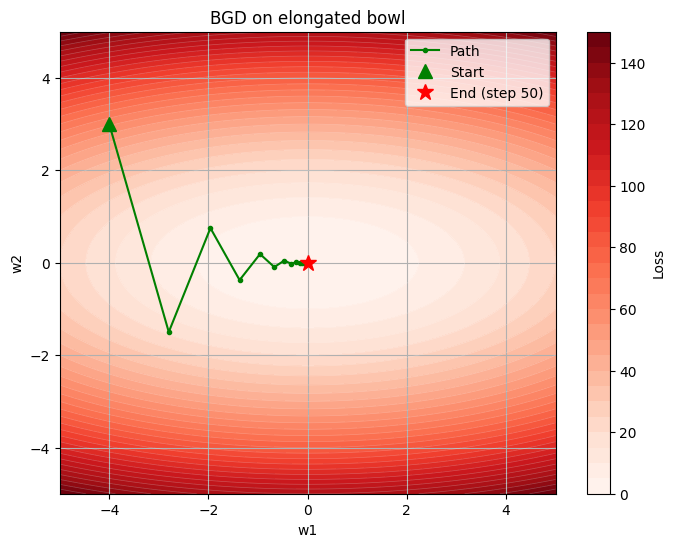

In [5]:
plt.figure(figsize=(8, 6))
bgd = BGD(lr=0.15)
bgd.plot(max_iter=50, title="BGD on elongated bowl")

### 2. Stochastic Gradient Descent (SGD)

SGD takes a step after every single randomly chosen sample, so the gradient is a noisy estimate of the true gradient!

1. Pick random $i \in \{1, \ldots, m\}$
2. $W \leftarrow W - \alpha \cdot \nabla_W \mathcal{L}^{(i)}$

In [6]:
class SGD(Optimizer):
    """
    Stochastic Gradient Descent.

    Update rule
    -----------
    W <- W - lr * dW   (same as BGD, but dW is from 1 sample only)
    b <- b - lr * db
    """

    def get_batch(self, X, y):
        i = np.random.randint(0, X.shape[0])
        return X[[i], :], y[[i], :]  # keep batch dim = shape (1, n_features)

    def update(self, layer):
        layer.W -= self.lr * layer.dW
        layer.b -= self.lr * layer.db

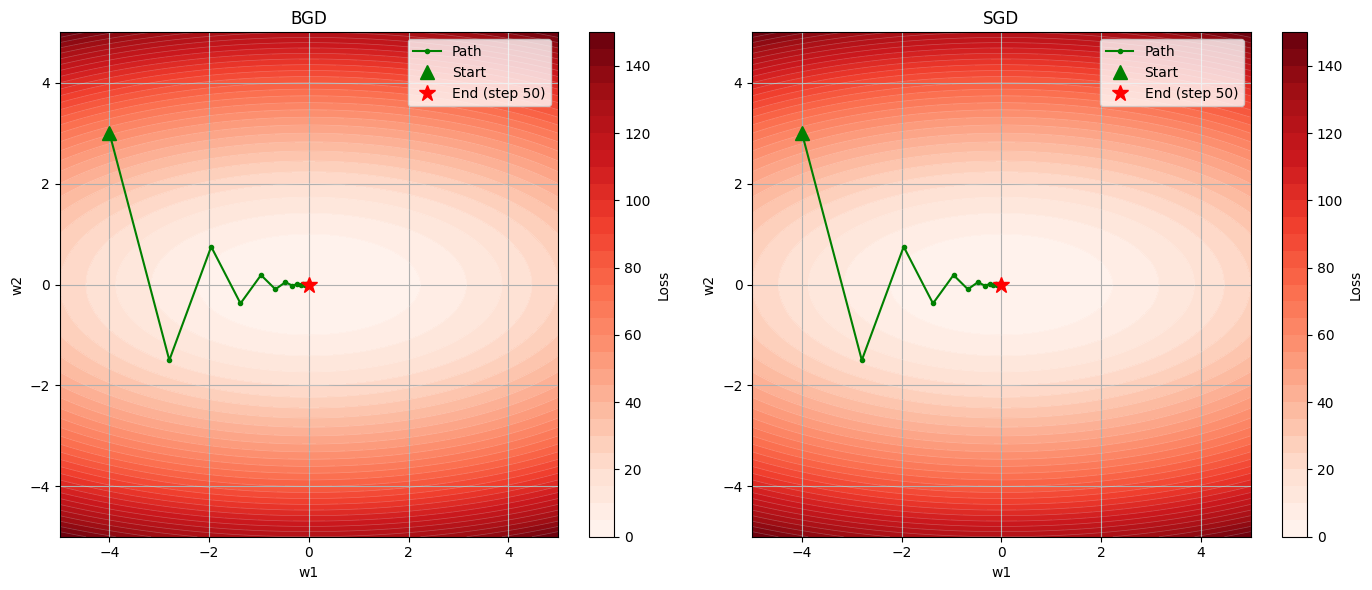

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axs[0])
BGD(lr=0.15).plot(max_iter=50, title="BGD")

plt.sca(axs[1])
SGD(lr=0.15).plot(max_iter=50, title="SGD")

plt.tight_layout()
plt.show()

### 3. Mini-Batch Gradient Descent (MBGD)

Instead of the full dataset or a single sample, it picks a random subset of $B$ samples per step.

1. Pick random $\mathcal{B} \subset \{1, \ldots, m\}$, $|\mathcal{B}| = B$

2. $W \leftarrow W - \alpha \cdot \frac{1}{B} \sum_{i \in \mathcal{B}} \nabla_W \mathcal{L}^{(i)}$

In [8]:
class MBGD(Optimizer):
    """
    Mini-Batch Gradient Descent.

    Parameters
    ----------
    lr         : float - learning rate
    batch_size : int   - number of samples per update step

    Update rule
    -----------
    W <- W - lr * dW   (dW averaged over batch_size samples)
    b <- b - lr * db
    """

    def __init__(self, lr=0.001, batch_size=32):
        super().__init__(lr)
        self.batch_size = batch_size

    def get_batch(self, X, y):
        m = X.shape[0]
        idx = np.random.choice(m, size=self.batch_size, replace=False)
        return X[idx], y[idx]

    def update(self, layer):
        layer.W -= self.lr * layer.dW
        layer.b -= self.lr * layer.db

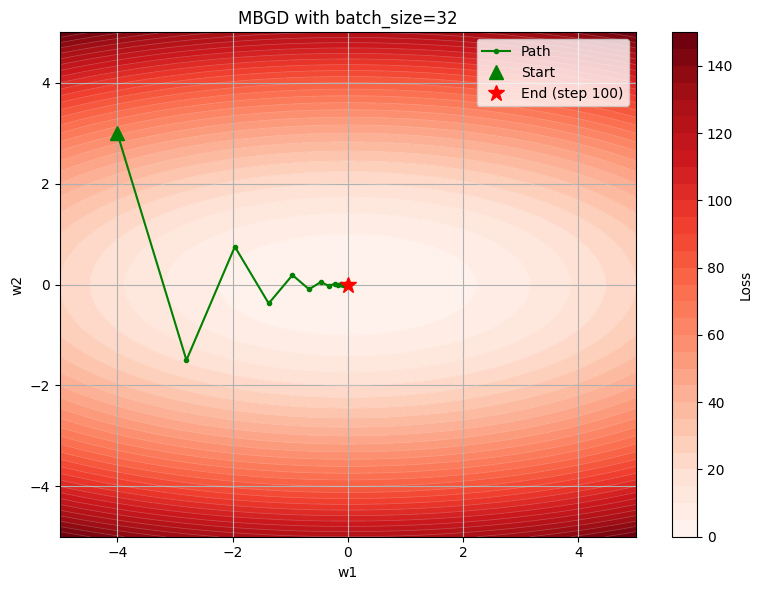

In [9]:
plt.figure(figsize=(8, 6))

bs = 32
MBGD(lr=0.15, batch_size=bs).plot(max_iter=100, title=f"MBGD with batch_size={bs}")

plt.tight_layout()
plt.show()

### 4. Momentum-based Gradient Descent

Steep, consistent directions build up speed; oscillating directions cancel out over time. $\beta$ controls how much of the previous velocity to retain.

$$
    \text{Velocity vector }v_W \leftarrow \beta \cdot v_W + (1 - \beta) \cdot \nabla_W \mathcal{L}
$$

$$
    W \leftarrow W - \alpha \cdot v_W
$$

In [10]:
class Momentum(Optimizer):
    """
    Gradient Descent with Momentum.

    Parameters
    ----------
    lr   : float - learning rate (alpha)
    beta : float - momentum coefficient, typically 0.9

    State per layer
    -------------------------------------------
    vW : velocity for W, shape same as layer.W, init zeros
    vB : velocity for b, shape same as layer.b, init zeros

    Update rule
    -----------
    vW <- beta * vW + (1 - beta) * dW
    vB <- beta * vB + (1 - beta) * dB
    W  <- W - lr * vW
    b  <- b - lr * vB
    """

    def __init__(self, lr=0.001, beta=0.9):
        super().__init__(lr)
        self.beta = beta
        self._state = {}

    def update(self, layer):
        key = id(layer)

        # Lazy initialisation of velocity on first call, inspired from tensorflow ka code
        if key not in self._state:
            self._state[key] = {
                "vW": np.zeros_like(layer.W),
                "vB": np.zeros_like(layer.b)
            }

        s = self._state[key]

        # Updating vel
        s["vW"] = self.beta * s["vW"] + (1 - self.beta) * layer.dW
        s["vB"] = self.beta * s["vB"] + (1 - self.beta) * layer.db

        # Updating params
        layer.W -= self.lr * s["vW"]
        layer.b -= self.lr * s["vB"]

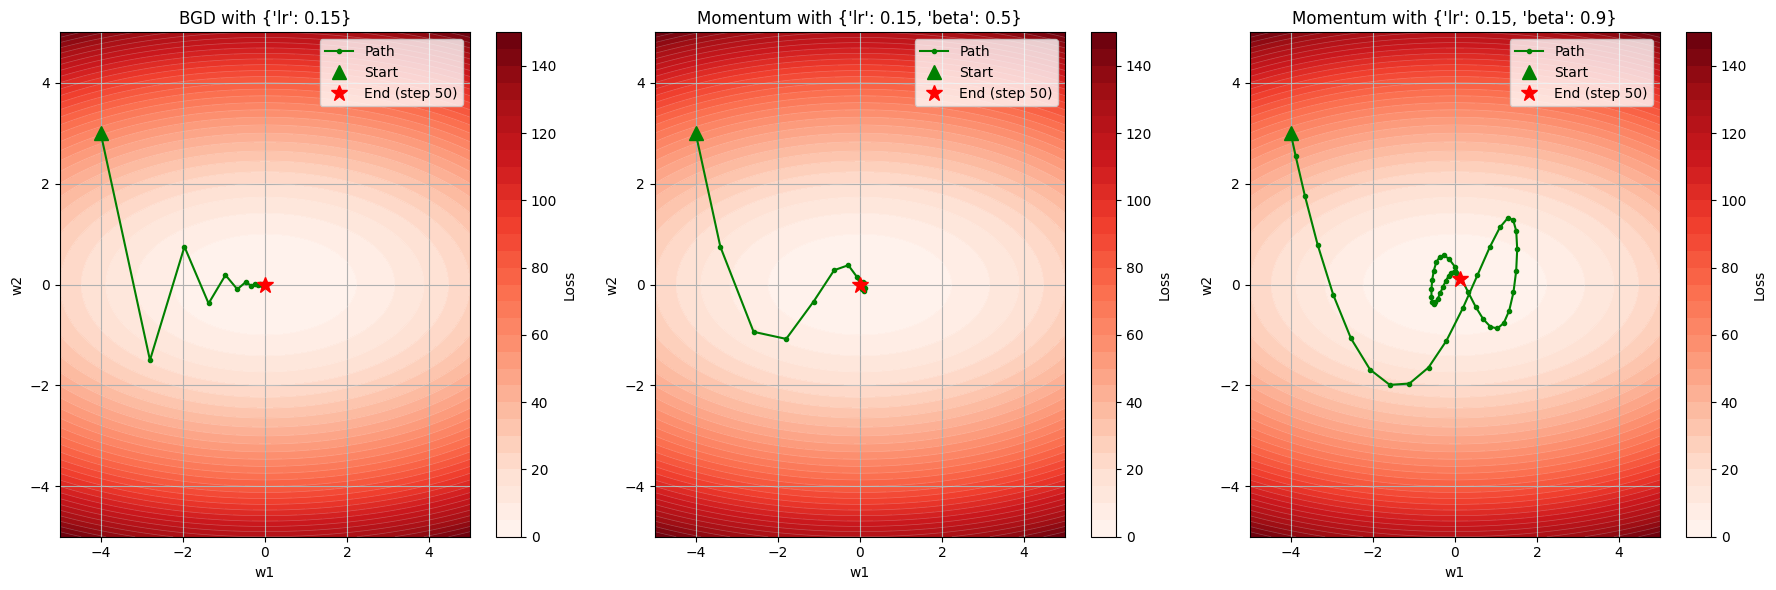

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

lr = 0.15
configs = [(BGD, dict(lr=lr)),
           (Momentum, dict(lr=lr, beta=0.5)),
           (Momentum, dict(lr=lr, beta=0.9))]

for ax, (cls, kwargs) in zip(axs, configs):
    plt.sca(ax)
    cls(**kwargs).plot(max_iter=50, title=f"{cls.__name__} with {kwargs}")

plt.tight_layout()
plt.show()

### 5. Nesterov-Accelerated Gradient Descent (NAG)

Nesterov prevents overshooting the minima with looking ahead first: compute the gradient not at the current position, but at the position we get after applying the current velocity.

$$
    \text{Lookahead postion } \tilde{W} = W - \alpha \cdot \beta \cdot v_W
$$
$$
    v_W \leftarrow \beta \cdot v_W + (1 - \beta) \cdot \nabla_W \mathcal{L}(\tilde{W})
$$
$$
    W \leftarrow W - \alpha \cdot v_W
$$

In [12]:
class NAG(Optimizer):
    """
    Nesterov Accelerated Gradient.

    Parameters
    ----------
    lr   : float - learning rate (alpha)
    beta : float - momentum coefficient, typically 0.9

    State per layer
    -------------------------------------------
    vW : velocity for W, shape same as layer.W, init zeros
    vB : velocity for b, shape same as layer.b, init zeros

    Update rule
    -----------
    W_look = W - lr * beta * vW          (lookahead)
    dW     = grad L(W_look)              (gradient at lookahead - should be done in plot() / Dense.backward())
    vW    <- beta * vW + (1 - beta) * dW
    W     <- W - lr * vW
    """

    def __init__(self, lr=0.001, beta=0.9):
        super().__init__(lr)
        self.beta = beta
        self._state = {}

    def update(self, layer):
        key = id(layer)

        if key not in self._state:
            self._state[key] = {
                "vW": np.zeros_like(layer.W),
                "vB": np.zeros_like(layer.b)
            }

        s = self._state[key]

        # dW in layer is already the lookahead gradient when called from plot()

        # Update velocity with the lookahead gradient
        s["vW"] = self.beta * s["vW"] + (1 - self.beta) * layer.dW
        s["vB"] = self.beta * s["vB"] + (1 - self.beta) * layer.db

        # Update parameters
        layer.W -= self.lr * s["vW"]
        layer.b -= self.lr * s["vB"]

    def apply_lookahead(self, layers):
        """
        Call BEFORE forward pass in Model.train().
        Shifts each Dense layer's weights to the lookahead position so
        that Dense.backward() computes the gradient at W_look.
        Saves the original weights for restoration after the update.
        """
        for layer in layers:
            if not hasattr(layer, "W"):
                continue
            key = id(layer)
            if key not in self._state:
                self._state[key] = {
                    "vW": np.zeros_like(layer.W),
                    "vB": np.zeros_like(layer.b)
                }
            s = self._state[key]
            s["W_orig"] = layer.W.copy()
            s["b_orig"] = layer.b.copy()
            layer.W = layer.W - self.lr * self.beta * s["vW"]  # W_look
            layer.b = layer.b - self.lr * self.beta * s["vB"]

    def restore_weights(self, layers):
        """
        Call AFTER backward pass, BEFORE update() in Model.train().
        Restores original weights so update() moves from W, not W_look.
        """
        for layer in layers:
            if not hasattr(layer, "W"):
                continue
            s = self._state.get(id(layer), {})
            if "W_orig" in s:
                layer.W = s.pop("W_orig")
                layer.b = s.pop("b_orig")

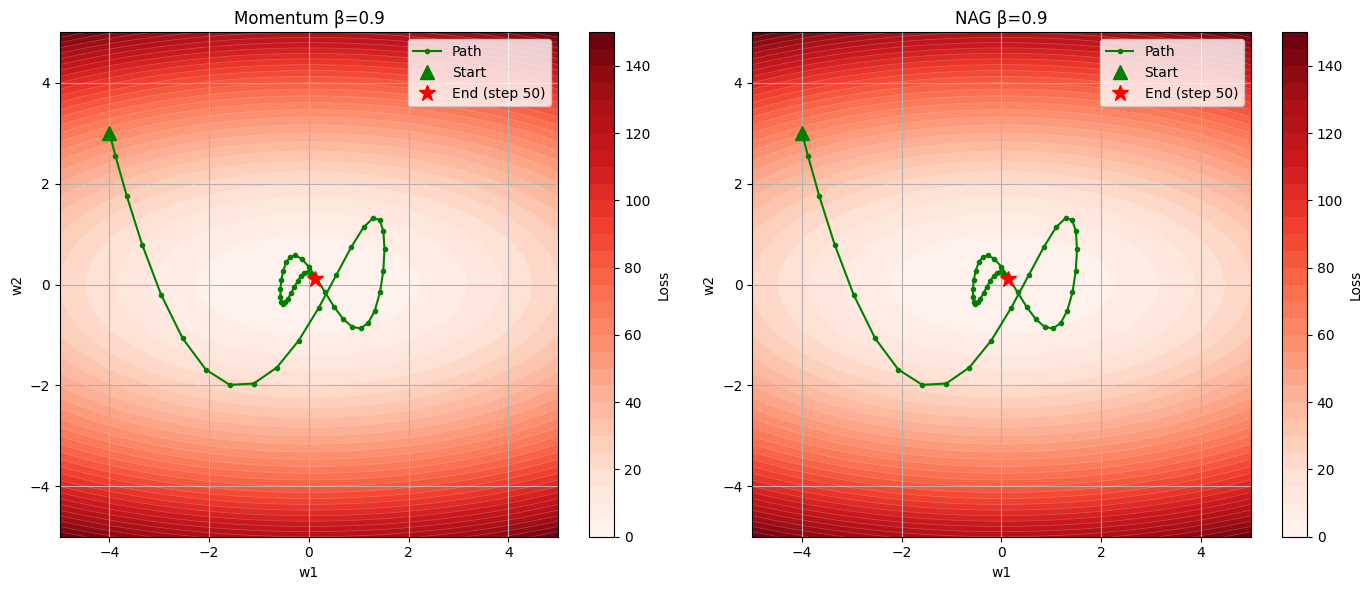

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

lr = 0.15
b = 0.9

plt.sca(axs[0])
Momentum(lr=lr, beta=b).plot(max_iter=50, title="Momentum β=0.9")

plt.sca(axs[1])
NAG(lr=lr, beta=b).plot(max_iter=50, title="NAG β=0.9")

plt.tight_layout()
plt.show()

### 6. Adaptive Gradient Algorithm (Adagrad)

### 7. Root Mean Squarre Propagation (RMSProp)

### 8. Adaptive Moment Estimation (Adam)